In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.metrics import (
    RocCurveDisplay,
    confusion_matrix,
    classification_report,
    roc_auc_score
)

from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold

In [17]:
import pandas as pd
from sklearn.model_selection import train_test_split

df = pd.read_csv("../data/WA_Fn-UseC_-Telco-Customer-Churn.csv")

df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

if "customerID" in df.columns:
    df.drop("customerID", axis=1, inplace=True)

X = df.drop("Churn", axis=1)
y = df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print(X_train.shape)
print(y_train.shape)

(5634, 19)
(5634,)


In [7]:
df.drop("customerID", axis=1, inplace=True)

df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df["TotalCharges"] = df["TotalCharges"].fillna(df["TotalCharges"].median())

df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

X = df.drop("Churn", axis=1)
y = df["Churn"]


In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [9]:
import joblib

model = joblib.load("../models/best_model.pkl")

print("Model Loaded Successfully")

Model Loaded Successfully


In [12]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.83      0.91      0.87      1035
           1       0.67      0.49      0.57       374

    accuracy                           0.80      1409
   macro avg       0.75      0.70      0.72      1409
weighted avg       0.79      0.80      0.79      1409



In [13]:
from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [3, 5, 7, 10],
    "learning_rate": [0.01, 0.05, 0.1]
}

In [10]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    random_state=42
)

In [12]:
param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [5, 10, 15, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

In [14]:
import pandas as pd

X_train = pd.read_csv("../data/X_train.csv")
X_test = pd.read_csv("../data/X_test.csv")

print(X_train.shape)
print(X_test.shape)

(5634, 19)
(1409, 19)


In [19]:
import joblib

preprocessor = joblib.load("../models/preprocessor.pkl")
best_model = joblib.load("../models/best_model.pkl")

In [20]:
print(df.columns)

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')


In [21]:
# Use saved best pipeline model
best_model = joblib.load("../models/best_model.pkl")

y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]

print("Prediction done")

Prediction done


Test AUC: 0.8454894210648687


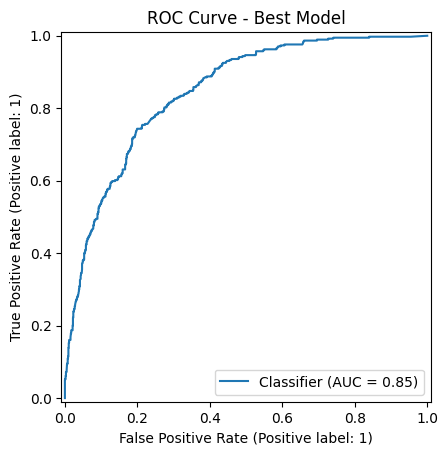

In [22]:
from sklearn.metrics import roc_auc_score, RocCurveDisplay
import matplotlib.pyplot as plt

auc = roc_auc_score(y_test, y_prob)

print("Test AUC:", auc)

RocCurveDisplay.from_predictions(y_test, y_prob)
plt.title("ROC Curve - Best Model")
plt.show()

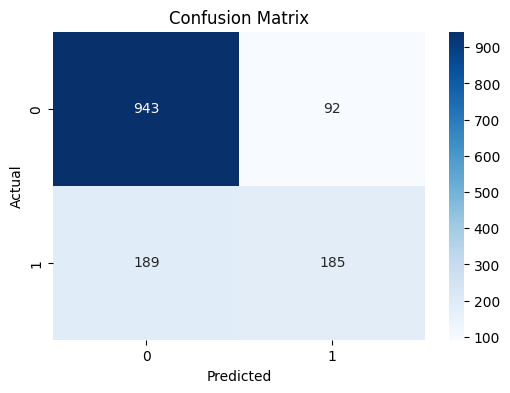

In [23]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm,
            annot=True,
            fmt="d",
            cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [24]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.83      0.91      0.87      1035
           1       0.67      0.49      0.57       374

    accuracy                           0.80      1409
   macro avg       0.75      0.70      0.72      1409
weighted avg       0.79      0.80      0.79      1409



In [25]:
model = best_model.named_steps["model"]

print(type(model))

<class 'sklearn.ensemble._gb.GradientBoostingClassifier'>


In [27]:
import pandas as pd

preprocessor = best_model.named_steps["prep"]
model = best_model.named_steps["model"]

num_features = preprocessor.transformers_[0][2]

cat_features = preprocessor.transformers_[1][1].get_feature_names_out(
    preprocessor.transformers_[1][2]
)

all_features = list(num_features) + list(cat_features)

feature_importance = pd.DataFrame({
    "Feature": all_features,
    "Importance": model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
35,Contract_Month-to-month,0.382567
1,tenure,0.176434
15,InternetService_Fiber optic,0.089188
17,OnlineSecurity_No,0.069010
2,MonthlyCharges,0.048039
26,TechSupport_No,0.046236
42,PaymentMethod_Electronic check,0.039905
38,PaperlessBilling_No,0.011056
11,MultipleLines_No,0.010448
37,Contract_Two year,0.008339


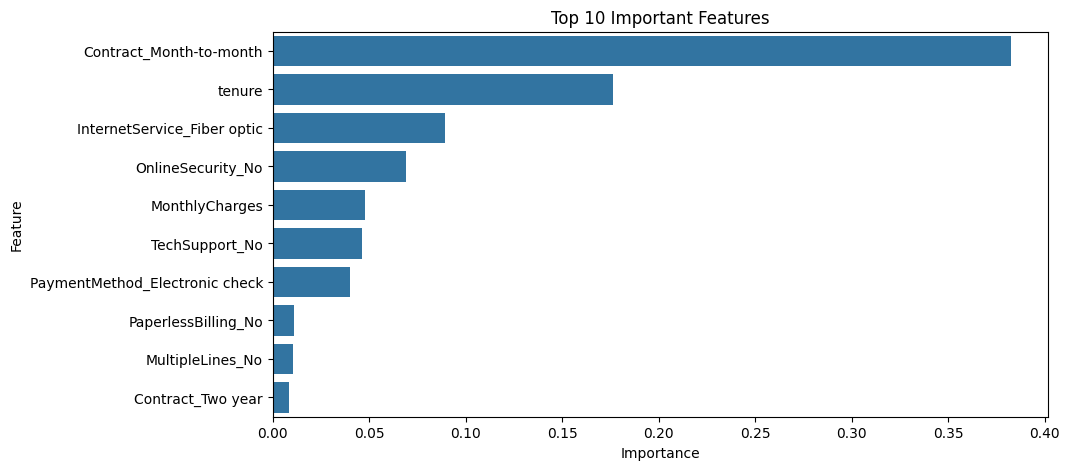

In [28]:
plt.figure(figsize=(10,5))

sns.barplot(
    x="Importance",
    y="Feature",
    data=feature_importance.head(10)
)

plt.title("Top 10 Important Features")
plt.show()

In [29]:
import joblib

joblib.dump(
    best_model,
    "../models/final_churn_model.pkl"
)

print("Final model saved")

Final model saved


In [30]:
loaded_model = joblib.load("../models/final_churn_model.pkl")

pred = loaded_model.predict(X_test[:5])

print(pred)

[0 1 0 0 0]
